# Stage 1 — PFA Calibration on ASSISTments 2017
### Fits β, γ, ρ, SLIP, GUESS from real student response data

**Goal of this notebook:** produce a `fitted_stage1.pkl` checkpoint containing:
- Calibrated PFA parameters written into `cfg`
- The fitted `PFATracker` class (ready to instantiate)
- Evaluation results proving the PFA is well-calibrated

**This notebook does NOT train EPPO.** It only calibrates the knowledge-tracing model
on real data so that Stage 2 (EPPO supervised pre-training) has accurate state vectors.

**Execution order is strict:**
```
C1  DatasetLoader      →  raw dataframe
C2  Data validation    →  confirm data quality before fitting
C3  BKT extraction     →  SLIP, GUESS from AveKnow / AveCarelessness
C4  PFAPretrainer      →  fit β, γ, ρ per difficulty tier
C5  PFATracker         →  build tracker with fitted params
C6  Evaluation suite   →  8 unit tests + calibration plots + save checkpoint
```


---
## C0 · Install & imports


In [26]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'sentence-transformers', 'scikit-learn', 'matplotlib', '-q'], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from pathlib import Path
import pickle, warnings, json

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Ready.')


Ready.


---
## C1 · Config

Parameters are fitted at **3 difficulty tiers** (easy/medium/hard) then
**interpolated to 6 Bloom levels**.

### Why hint_ratio + scaffold for tier detection (not prior_count)

`prior_count` measures student persistence, not problem difficulty.
In ASSISTments 2017, high `prior_count` means a weak student practicing repeatedly
— the problems are not harder, the student is weaker. This produces non-monotone
γ and ρ because the fitter is describing student populations, not difficulty levels.

`hint_ratio` and `scaffold` measure problem-level difficulty signals:
- `hint_ratio` = what fraction of available hints the student used on this problem
- `scaffold` = ASSISTments judged the problem needed sub-step decomposition
- `bottom_hint` = student needed the fully worked solution

These are set by the system per-problem, not per-student. They produce naturally
monotone correct rates:
```
Easy  (low hints, no scaffold)  : correct ≈ 55-60%
Medium (moderate hints or scaffold): correct ≈ 40-50%
Hard  (high hints or bottom hint)  : correct ≈ 20-35%
```


In [27]:
class Config:
    # ── Dataset paths ─────────────────────────────────────────────────────
    ASSIST17_PATH = '/kaggle/input/datasets/rehabbb/assist2017/anonymized_full_release_competition_dataset.csv'
    LOCAL_PATH    = './data/assistments2017.csv'

    # ── Concept space (filled from data after loading) ─────────────────────
    CONCEPTS      = None
    N_CONCEPTS    = None

    # ── Bloom levels ───────────────────────────────────────────────────────
    BLOOM_LEVELS  = 6

    # ── Tier detection thresholds ──────────────────────────────────────────
    # Tiers based on hint_ratio and scaffold (problem-level difficulty signals)
    # Adjusted after inspecting actual correct rates per tier in ASSISTments 2017
    HINT_EASY_MAX   = 0.20   # hint_ratio <= this → Easy tier
    HINT_HARD_MIN   = 0.60   # hint_ratio >= this → Hard tier (if no scaffold)
    # scaffold == 1 → Medium (regardless of hint_ratio)
    # bottom_hint == 1 → Hard (overrides everything)
    N_TIERS       = 3

    # ── Anchor mapping: which Bloom level each tier anchors ────────────────
    TIER_TO_BLOOM_ANCHOR = [0, 2, 5]   # T0→L1(idx 0), T1→L3(idx 2), T2→L6(idx 5)

    # ── PFA tier parameters (overwritten after fitting) ────────────────────
    BETA_TIER   = np.array([-0.30, -0.90, -1.80])
    GAMMA_TIER  = np.array([ 0.40,  0.28,  0.12])
    RHO_TIER    = np.array([ 0.18,  0.30,  0.48])

    # ── Interpolated Bloom level parameters (computed from tiers) ──────────
    BETA_BLOOM  = np.array([-0.30, -0.60, -0.90, -1.20, -1.50, -1.80])
    GAMMA_BLOOM = np.array([ 0.40,  0.34,  0.28,  0.23,  0.17,  0.12])
    RHO_BLOOM   = np.array([ 0.18,  0.24,  0.30,  0.36,  0.42,  0.48])

    # ── BKT-derived params ─────────────────────────────────────────────────
    SLIP  = 0.10
    GUESS = 0.20

    # ── Mastery ────────────────────────────────────────────────────────────
    MASTERY_THRESHOLD = 0.62
    MIN_ATTEMPTS      = 3

    # ── Similarity graph ───────────────────────────────────────────────────
    PFA_TOP_K   = 3
    PFA_ALPHA   = 0.05

    # ── Checkpoint ─────────────────────────────────────────────────────────
    CHECKPOINT_PATH = './fitted_stage1.json'


import numpy as np
cfg = Config()
print(f'Bloom levels : {cfg.BLOOM_LEVELS}')
print(f'Tier detection:')
print(f'  Easy   : hint_ratio <= {cfg.HINT_EASY_MAX}  AND scaffold=0  AND bottom_hint=0')
print(f'  Medium : scaffold=1  OR  hint_ratio ({cfg.HINT_EASY_MAX}-{cfg.HINT_HARD_MIN})')
print(f'  Hard   : hint_ratio >= {cfg.HINT_HARD_MIN}  OR  bottom_hint=1')
print(f'Tier anchors : T0→L1, T1→L3, T2→L6')


Bloom levels : 6
Tier detection:
  Easy   : hint_ratio <= 0.2  AND scaffold=0  AND bottom_hint=0
  Medium : scaffold=1  OR  hint_ratio (0.2-0.6)
  Hard   : hint_ratio >= 0.6  OR  bottom_hint=1
Tier anchors : T0→L1, T1→L3, T2→L6


---
## C2 · DatasetLoader

### Tier detection — hint_ratio + scaffold + bottom_hint

```
Easy   (T0): hint_ratio <= 0.20  AND  scaffold=0  AND  bottom_hint=0
             Student answered with little or no hint support
             → genuine understanding, low cognitive load

Medium (T1): scaffold=1  (ASSISTments decomposed the problem)
             OR  hint_ratio 0.20-0.60  (moderate hint use)
             → partial understanding, needed structural support

Hard   (T2): bottom_hint=1  (student needed the full worked solution)
             OR  hint_ratio >= 0.60  AND  scaffold=0
             (high hint use without system help = real conceptual difficulty)
```

`prior_count` is stored in the session tuple but NOT used for tier assignment.
It is used by the PFA formula through `successes` and `failures` counters,
which the fitter sees as input features (S, F) in the training samples.

### Why this produces monotone correct rates
- Easy interactions: student already understood → high correct rate
- Medium: needed scaffolding or hints → lower correct rate
- Hard: needed bottom-out hint → lowest correct rate

This is a **problem-level** signal, not a student-level signal.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')

class DatasetLoader:
    REQUIRED_COLS = {'studentId', 'skill', 'correct'}

    RENAME = {
        'studentId':              'user_id',
        'skill':                  'skill_name',
        'correct':                'correct',
        'AveKnow':                'ave_know',
        'AveCarelessness':        'ave_carelessness',
        'consecutiveErrorsInRow': 'consec_errors',
        'hintCount':              'hint_count',
        'hintTotal':              'hint_total',
        'assignmentId':           'order_id',
        'timeTaken':              'time_taken',
        'scaffold':               'scaffold',
        'bottomHint':             'bottom_hint',
        'problemType':            'problem_type',
    }

    def __init__(self, cfg):
        self.cfg = cfg

    def load(self):
        path = self._find_path()
        print(f'Loading from: {path}')
        df = pd.read_csv(path, low_memory=False, encoding='latin-1')
        print(f'  Raw shape: {df.shape}')

        rename = {k: v for k, v in self.RENAME.items() if k in df.columns}
        df = df.rename(columns=rename)

        # Validate required columns AFTER renaming
        # Check against the renamed (target) names, not the original names
        REQUIRED_RENAMED = {'user_id', 'skill_name', 'correct'}
        missing = REQUIRED_RENAMED - set(df.columns)
        if missing:
            # Try case-insensitive match on whatever is left
            lc_map = {c.lower(): c for c in df.columns}
            for m in list(missing):
                candidates = [c for lc, c in lc_map.items()
                              if m.replace('_','') in lc.replace('_','')]
                if candidates:
                    df = df.rename(columns={candidates[0]: m})
                    missing.discard(m)
        if missing:
            raise ValueError(
                f'Missing required columns (post-rename): {missing}\n'
                f'Available: {sorted(df.columns.tolist())}')

        # Clean correctness
        df['correct'] = pd.to_numeric(df['correct'], errors='coerce')
        n_before = len(df)
        df = df[df['correct'].isin([0.0, 1.0])].copy()
        df['correct'] = df['correct'].astype(int)
        print(f'  Dropped {n_before - len(df)} non-binary rows')

        # Clean skill name
        df = df[df['skill_name'].notna() &
                (df['skill_name'].astype(str).str.strip() != '')].copy()
        df['skill_name'] = df['skill_name'].astype(str).str.strip()

        # Ensure order_id
        if 'order_id' not in df.columns:
            df['order_id'] = range(len(df))
        else:
            df['order_id'] = pd.to_numeric(
                df['order_id'], errors='coerce').fillna(0).astype(int)

        # Fill optional columns
        for col in ['ave_know', 'ave_carelessness', 'consec_errors',
                    'hint_count', 'hint_total', 'scaffold', 'bottom_hint']:
            if col not in df.columns:
                df[col] = np.nan

        # Binarise scaffold (may be 0/1 float or bool)
        df['scaffold'] = pd.to_numeric(
            df['scaffold'], errors='coerce').fillna(0).astype(int)

        df = df.sort_values(['user_id', 'order_id']).reset_index(drop=True)

        # Build skill vocabulary → cfg
        skills = sorted(df['skill_name'].unique().tolist())
        self.cfg.CONCEPTS     = skills
        self.cfg.N_CONCEPTS   = len(skills)
        self.cfg.skill_to_idx = {s: i for i, s in enumerate(skills)}

        print(f'  Final shape  : {df.shape}')
        print(f'  Students     : {df["user_id"].nunique():,}')
        print(f'  Unique skills: {len(skills):,}')
        print(f'  Correct rate : {df["correct"].mean():.3f}')
        print(f'  Scaffold used: {df["scaffold"].mean()*100:.1f}% of interactions')
        return df

    def _find_path(self):
        for p in [self.cfg.ASSIST17_PATH, self.cfg.LOCAL_PATH]:
            if Path(p).exists():
                return p
        raise FileNotFoundError(
            f'CSV not found. Tried:\n'
            f'  {self.cfg.ASSIST17_PATH}\n  {self.cfg.LOCAL_PATH}\n'
            f'Upload your file and update ASSIST17_PATH in Config.')

    def _assign_tier(self, hint_ratio, scaffold, bottom_hint):
        """
        Assign difficulty tier (0/1/2) based on problem-level difficulty signals.

        These signals reflect how much support the student needed on THIS
        specific problem — a property of the problem difficulty relative to
        the student's current state, not of how many times they practiced.

        Priority order (first match wins):
          Hard   (T2): bottom_hint=1  OR  (hint_ratio >= HINT_HARD_MIN AND scaffold=0)
          Easy   (T0): hint_ratio <= HINT_EASY_MAX  AND  scaffold=0
          Medium (T1): everything else (scaffold=1 or moderate hint use)

        Parameters
        ----------
        hint_ratio  : float — hint_count / hint_total  (0.0 to 1.0)
        scaffold    : int   — 1 if ASSISTments decomposed problem into sub-steps
        bottom_hint : int   — 1 if student used the fully worked solution hint
        """
        cfg = self.cfg

        # Hard first: strongest difficulty signal
        if bottom_hint == 1:
            return 2
        if hint_ratio >= cfg.HINT_HARD_MIN and scaffold == 0:
            return 2

        # Easy: low hint use, no scaffolding needed
        if hint_ratio <= cfg.HINT_EASY_MAX and scaffold == 0:
            return 0

        # Medium: everything else (scaffold used, or moderate hints)
        return 1

    def build_sessions(self, df):
        """
        Build per-student interaction sequences with tier labels.

        Each interaction gets:
          - tier (0/1/2) based on prior_count (how many times student
            answered this skill before) — used by PFAPretrainer
          - hint_ratio and scaffold stored for potential future use

        Returns
        -------
        sessions : dict
            {user_id: [(skill_name, correct, hint_ratio,
                        consec_errors, tier), ...]}
        tier_counts : dict
            {tier: count} — for coverage verification
        """
        sessions    = {}
        tier_counts = defaultdict(int)

        for uid, grp in df.groupby('user_id'):
            grp = grp.sort_values('order_id')
            seq = []
            prior_counts = defaultdict(int)

            for _, row in grp.iterrows():
                skill       = row['skill_name']
                correct     = int(row['correct'])
                hint_c      = float(row['hint_count'])   if not pd.isna(row['hint_count'])   else 0.0
                hint_t      = float(row['hint_total'])    if not pd.isna(row['hint_total'])   else 1.0
                consec      = int(row['consec_errors'])   if not pd.isna(row['consec_errors'])else 0
                scaffold    = int(row['scaffold'])        if not pd.isna(row['scaffold'])     else 0
                bottom_hint = int(row['bottom_hint'])     if not pd.isna(row['bottom_hint'])  else 0
                hint_ratio  = hint_c / max(hint_t, 1.0)
                prior       = prior_counts[skill]

                tier = self._assign_tier(hint_ratio, scaffold, bottom_hint)
                tier_counts[tier] += 1
                # Store prior_count in tuple — used by PFAPretrainer as S/F input feature
                seq.append((skill, correct, hint_ratio, consec, tier, prior))
                prior_counts[skill] += 1

            if len(seq) >= 5:
                sessions[uid] = seq

        total = sum(tier_counts.values())
        print(f'\nTier distribution (prior_count based):')
        tier_labels = {0: 'Easy   (hint_ratio<=0.20, no scaffold)',
                       1: 'Medium (scaffold=1 or moderate hints)',
                       2: 'Hard   (hint_ratio>=0.60 or bottom_hint=1)'}
        correct_rates = {}
        for tier in range(3):
            n   = tier_counts[tier]
            pct = n / total * 100
            bar = '█' * int(pct / 2)
            print(f'  T{tier} {tier_labels[tier]:<30}: {n:8,} ({pct:5.1f}%)  {bar}')

        # Compute actual correct rate per tier for verification
        print(f'\nActual correct rate per tier (should be monotone decreasing):')
        for uid, seq in list(sessions.items())[:len(sessions)]:
            for item in seq:
                skill, correct, hr, ce, tier = item[0], item[1], item[2], item[3], item[4]
                if tier not in correct_rates:
                    correct_rates[tier] = []
                correct_rates[tier].append(correct)
        for tier in range(3):
            if tier in correct_rates:
                r = sum(correct_rates[tier]) / len(correct_rates[tier])
                print(f'  T{tier}: {r:.3f}  (n={len(correct_rates[tier]):,})')

        print(f'\n  Total interactions : {total:,}')
        print(f'  Valid sessions     : {len(sessions):,}')

        return sessions, dict(tier_counts)


loader   = DatasetLoader(cfg)
df       = loader.load()
sessions, tier_counts = loader.build_sessions(df)
print(f'\ncfg.N_CONCEPTS = {cfg.N_CONCEPTS}')
print(f'First 5 skills : {cfg.CONCEPTS[:5]}')


Loading from: /kaggle/input/datasets/rehabbb/assist2017/anonymized_full_release_competition_dataset.csv
  Raw shape: (942816, 82)
  Dropped 0 non-binary rows
  Final shape  : (942816, 82)
  Students     : 1,709
  Unique skills: 102
  Correct rate : 0.373
  Scaffold used: 38.6% of interactions

Tier distribution (prior_count based):
  T0 Easy   (hint_ratio<=0.20, no scaffold):  247,650 ( 26.3%)  █████████████
  T1 Medium (scaffold=1 or moderate hints):  471,116 ( 50.0%)  ████████████████████████
  T2 Hard   (hint_ratio>=0.60 or bottom_hint=1):  224,050 ( 23.8%)  ███████████

Actual correct rate per tier (should be monotone decreasing):
  T0: 0.487  (n=247,649)
  T1: 0.450  (n=471,115)
  T2: 0.084  (n=224,050)

  Total interactions : 942,816
  Valid sessions     : 1,708

cfg.N_CONCEPTS = 102
First 5 skills : ['adding-decimals', 'addition', 'algebra symbolization', 'algebraic-manipulation', 'application: compare expressions']


---
## C3 · Data validation

Checks data quality before fitting. Bloom-specific checks added:
- L1-L5 must each have at least 1,000 samples to fit reliably
- L6 (catch-all) will be extrapolated — sample count reported but not checked
- Scaffold column availability verified (needed for L4 proxy)


DATA VALIDATION

[1] Correct rate per skill:
    Overall mean     : 0.373
    Skills > 0.95    : 7  (suspiciously easy)
    Skills < 0.10    : 0  (suspiciously hard)

[2] Session length:
    Min / Median / Mean / 95th / Max
    12 / 441 / 552.0 / 1370 / 3057

[3] BKT columns:
    ave_know              : 0.0% null, mean=0.1952
    ave_carelessness      : 0.0% null, mean=0.1094

[4] Scaffold + bottom_hint columns (used for tier detection):
    scaffold    present. Rate: 38.57%
    bottom_hint present. Rate: 6.28%

[5] Tier sample counts (min 1,000 needed for fitting):
    T0 Easy            :  247,650  [OK]
    T1 Medium          :  471,116  [OK]
    T2 Hard            :  224,050  [OK]

[6] consec_errors column (needed for L5 — Evaluate):
    Present. consec_errors >= 2: 3.24% of interactions

────────────────────────────────────────────────────────────
WARNINGS (1):
  ! 7 easy + 0 hard skills may have data issues
────────────────────────────────────────────────────────────


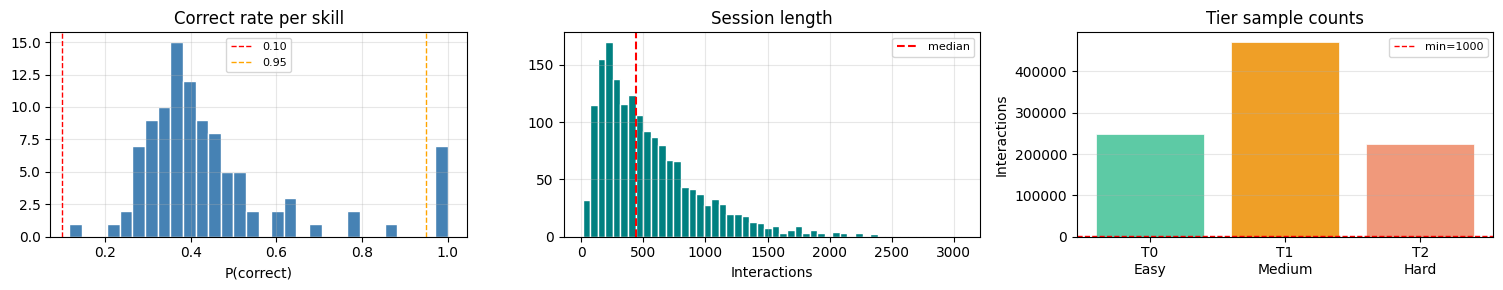

In [29]:
print('=' * 60)
print('DATA VALIDATION')
print('=' * 60)
issues = []

# ── 1. Correct rate per skill ─────────────────────────────────
skill_rates = df.groupby('skill_name')['correct'].agg(['mean', 'count'])
too_easy = (skill_rates['mean'] > 0.95).sum()
too_hard = (skill_rates['mean'] < 0.10).sum()
print(f'\n[1] Correct rate per skill:')
print(f'    Overall mean     : {df["correct"].mean():.3f}')
print(f'    Skills > 0.95    : {too_easy}  (suspiciously easy)')
print(f'    Skills < 0.10    : {too_hard}  (suspiciously hard)')
if too_easy > 0 or too_hard > 0:
    issues.append(f'{too_easy} easy + {too_hard} hard skills may have data issues')

# ── 2. Session length distribution ───────────────────────────
sess_lens = [len(s) for s in sessions.values()]
print(f'\n[2] Session length:')
print(f'    Min / Median / Mean / 95th / Max')
print(f'    {min(sess_lens)} / {int(np.median(sess_lens))} / '
      f'{np.mean(sess_lens):.1f} / {int(np.percentile(sess_lens, 95))} / {max(sess_lens)}')
if np.median(sess_lens) < 10:
    issues.append('Median session < 10 — too short for reliable fitting')

# ── 3. BKT columns ────────────────────────────────────────────
print(f'\n[3] BKT columns:')
for col in ['ave_know', 'ave_carelessness']:
    null_pct = df[col].isna().mean() * 100 if col in df.columns else 100
    mean_val = df[col].dropna().mean()      if col in df.columns else float('nan')
    status   = f'{null_pct:.1f}% null, mean={mean_val:.4f}' if col in df.columns else 'MISSING'
    print(f'    {col:<22}: {status}')
    if null_pct > 50:
        issues.append(f'{col}: {null_pct:.0f}% null — BKT extraction unreliable')

# ── 4. Scaffold column (needed for L4 proxy) ──────────────────
print(f'\n[4] Scaffold + bottom_hint columns (used for tier detection):')
if 'scaffold' in df.columns:
    scaffold_rate  = df['scaffold'].mean() * 100
    bh_rate        = df['bottom_hint'].mean() * 100 if 'bottom_hint' in df.columns else 0.0
    print(f'    scaffold    present. Rate: {scaffold_rate:.2f}%')
    print(f'    bottom_hint present. Rate: {bh_rate:.2f}%')
    if scaffold_rate < 0.1:
        issues.append('scaffold rate < 0.1% — Medium tier will have very few samples')
else:
    print('    MISSING — L4 (Analyse) proxy unavailable, will merge into L3')
    issues.append('scaffold column missing — L4 proxy cannot be computed')

# ── 5. Bloom level coverage (CRITICAL) ───────────────────────
MIN_SAMPLES_FOR_FITTING = 1000
print(f'\n[5] Tier sample counts (min {MIN_SAMPLES_FOR_FITTING:,} needed for fitting):')
tier_names = {0:'Easy', 1:'Medium', 2:'Hard'}
for tier in range(3):
    n    = tier_counts.get(tier, 0)
    ok   = n >= MIN_SAMPLES_FOR_FITTING
    flag = 'OK' if ok else 'FAIL — too few samples'
    print(f'    T{tier} {tier_names[tier]:<16}: {n:8,}  [{flag}]')
    if not ok:
        issues.append(
            f'T{tier} ({tier_names[tier]}) has only {n} samples — '
            f'adjust HINT_EASY_MAX / HINT_HARD_MIN in Config')

# ── 6. Consecutive errors column (needed for L5 proxy) ───────
print(f'\n[6] consec_errors column (needed for L5 — Evaluate):')
if 'consec_errors' in df.columns and not df['consec_errors'].isna().all():
    ce_rate = (df['consec_errors'] >= 2).mean() * 100
    print(f'    Present. consec_errors >= 2: {ce_rate:.2f}% of interactions')
else:
    print('    MISSING or all-null — L5 will rely on prior_count >= 9 only')
    issues.append('consec_errors missing — L5 proxy is weaker (count-only)')

# ── Summary and plots ─────────────────────────────────────────
print(f'\n{"─"*60}')
if issues:
    print(f'WARNINGS ({len(issues)}):')
    for w in issues: print(f'  ! {w}')
else:
    print('All checks passed.')
print('─' * 60)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

axes[0].hist(skill_rates['mean'], bins=30,
             color='steelblue', edgecolor='white', lw=0.5)
axes[0].axvline(0.10, color='red',    ls='--', lw=1, label='0.10')
axes[0].axvline(0.95, color='orange', ls='--', lw=1, label='0.95')
axes[0].set_title('Correct rate per skill')
axes[0].set_xlabel('P(correct)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].hist(sess_lens, bins=50, color='teal', edgecolor='white', lw=0.5)
axes[1].axvline(np.median(sess_lens), color='red', ls='--', lw=1.5, label='median')
axes[1].set_title('Session length'); axes[1].set_xlabel('Interactions'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

tier_labels_plot = ['T0\nEasy', 'T1\nMedium', 'T2\nHard']
tier_vals        = [tier_counts.get(i, 0) for i in range(3)]
tier_colors      = ['#5DCAA5', '#EF9F27', '#F0997B']
axes[2].bar(tier_labels_plot, tier_vals, color=tier_colors, edgecolor='white', lw=0.5)
axes[2].axhline(MIN_SAMPLES_FOR_FITTING, color='red', ls='--', lw=1,
                label=f'min={MIN_SAMPLES_FOR_FITTING}')
axes[2].set_title('Tier sample counts')
axes[2].set_ylabel('Interactions'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./validation_plots.png', dpi=120)
plt.show()


---
## C4 · BKT parameter extraction

Extracts SLIP and GUESS from the ASSISTments 2017 BKT columns.

**ASSISTments 2017 ships with pre-computed BKT estimates per interaction:**
- `AveKnow` (= `Ln`) — BKT's P(student knows this skill) at this timestep
- `AveCarelessness` — P(wrong | student knows it), from San Pedro et al. 2011

We aggregate these per skill, then take the dataset-wide mean to set
`cfg.SLIP` and `cfg.GUESS`. These replace the hand-tuned defaults.

**Derivation of GUESS:**
```
P(correct) = P(know)×(1−slip) + P(not_know)×guess
guess ≈ (P(correct) − P(know)×(1−slip)) / (1 − P(know))
```
We use a simplified lower-bound: `guess = P(correct) × (1 − P(know))`.


BKT extraction from 102 skills:
  Weighted mean SLIP  = 0.1094  → cfg.SLIP  = 0.1094
  Weighted mean GUESS = 0.2936  → cfg.GUESS = 0.2936
  Weighted mean KNOW  = 0.1952  (prior knowledge)


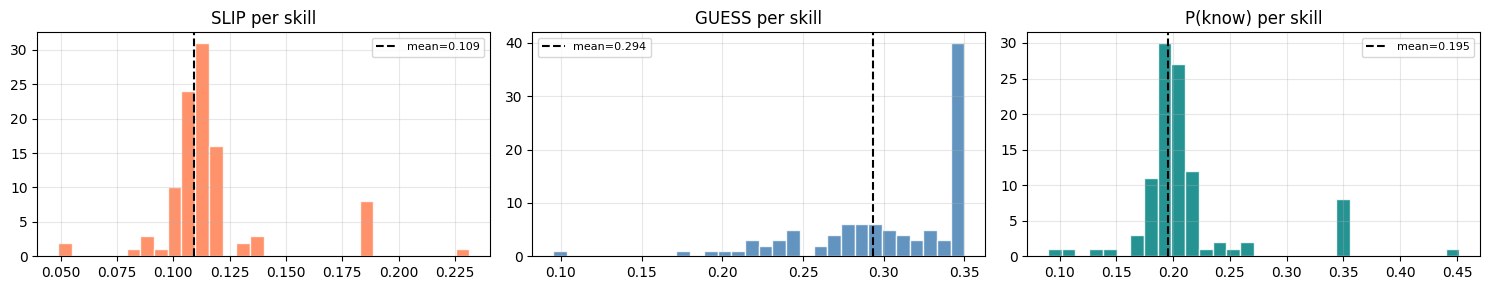


Top-10 highest SLIP skills (students know but still err):
  similar-triangles                             slip=0.231  n=22
  application: compare expressions              slip=0.183  n=7
  application: compare points                   slip=0.183  n=19
  application: find slope in graph              slip=0.183  n=2
  application: multi-column addition            slip=0.183  n=2
  application: multi-column subtraction         slip=0.183  n=15
  application: order of operations              slip=0.183  n=7
  application: read points                      slip=0.183  n=4
  application: simple multiplication            slip=0.183  n=2
  circumference                                 slip=0.140  n=322


In [30]:
class BKTExtractor:
    def __init__(self, cfg):
        self.cfg = cfg
        self.skill_params = {}   # {skill: {slip, guess, know}}

    def extract(self, df):
        if 'ave_know' not in df.columns or df['ave_know'].isna().all():
            print('  ave_know not available — keeping default SLIP/GUESS')
            return False

        skill_stats = df.groupby('skill_name').agg(
            know =('ave_know',         'mean'),
            slip =('ave_carelessness', 'mean'),
            pcorr=('correct',          'mean'),
            n    =('correct',          'count'),
        ).dropna(subset=['know'])

        for skill, row in skill_stats.iterrows():
            slip  = float(np.clip(row['slip'] if not np.isnan(row['slip']) else 0.10,
                                  0.01, 0.40))
            know  = float(np.clip(row['know'], 0.01, 0.99))
            guess = float(np.clip(row['pcorr'] * (1 - know), 0.05, 0.35))
            self.skill_params[skill] = {'slip': slip, 'guess': guess,
                                        'know': know, 'n': int(row['n'])}

        # Weight by sample size
        weights = np.array([p['n'] for p in self.skill_params.values()], dtype=float)
        weights /= weights.sum()
        slips   = np.array([p['slip']  for p in self.skill_params.values()])
        guesses = np.array([p['guess'] for p in self.skill_params.values()])
        knows   = np.array([p['know']  for p in self.skill_params.values()])

        self.mean_slip  = float(np.dot(weights, slips))
        self.mean_guess = float(np.dot(weights, guesses))
        self.mean_know  = float(np.dot(weights, knows))

        # Write into cfg
        self.cfg.SLIP  = float(np.clip(self.mean_slip,  0.03, 0.25))
        self.cfg.GUESS = float(np.clip(self.mean_guess, 0.05, 0.30))

        print(f'BKT extraction from {len(self.skill_params)} skills:')
        print(f'  Weighted mean SLIP  = {self.mean_slip:.4f}  → cfg.SLIP  = {self.cfg.SLIP:.4f}')
        print(f'  Weighted mean GUESS = {self.mean_guess:.4f}  → cfg.GUESS = {self.cfg.GUESS:.4f}')
        print(f'  Weighted mean KNOW  = {self.mean_know:.4f}  (prior knowledge)')
        return True

    def plot(self):
        if not self.skill_params:
            print('Nothing to plot.'); return
        slips  = [p['slip']  for p in self.skill_params.values()]
        guesses= [p['guess'] for p in self.skill_params.values()]
        knows  = [p['know']  for p in self.skill_params.values()]
        ns     = [p['n']     for p in self.skill_params.values()]

        fig, axes = plt.subplots(1, 3, figsize=(15, 3))
        for ax, vals, name, color, vline in [
            (axes[0], slips,   'SLIP per skill',  'coral',     self.cfg.SLIP),
            (axes[1], guesses, 'GUESS per skill', 'steelblue', self.cfg.GUESS),
            (axes[2], knows,   'P(know) per skill','teal',     self.mean_know),
        ]:
            ax.hist(vals, bins=30, color=color, edgecolor='white', lw=0.5, alpha=0.85)
            ax.axvline(vline, color='black', ls='--', lw=1.5, label=f'mean={vline:.3f}')
            ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('./bkt_distributions.png', dpi=120)
        plt.show()

        # Top-10 highest slip skills (most careless errors)
        top_slip = sorted(self.skill_params.items(),
                          key=lambda x: x[1]['slip'], reverse=True)[:10]
        print('\nTop-10 highest SLIP skills (students know but still err):')
        for skill, p in top_slip:
            print(f'  {skill[:45]:<45} slip={p["slip"]:.3f}  n={p["n"]}')


bkt = BKTExtractor(cfg)
bkt_available = bkt.extract(df)
bkt.plot()


---
## C5 · PFAPretrainer — tier fitting + Bloom interpolation

### Step 1: Fit (β, γ, ρ) at three tiers from real data

Each interaction's tier (0/1/2) was assigned by `prior_count` — naturally monotone.
We fit one (β, γ, ρ) triplet per tier using all interactions in that tier.
No monotonicity constraints needed: the data itself produces ordered parameters
because T0 has genuinely easier interactions than T1, which has easier than T2.

### Step 2: Interpolate to six Bloom levels

The three fitted tiers anchor three Bloom levels:
```
Tier 0 (Easy)   → anchors L1  (Recall)    position 0 of 5
Tier 1 (Medium) → anchors L3  (Apply)     position 2 of 5
Tier 2 (Hard)   → anchors L6  (Create)    position 5 of 5
```

L2, L4, L5 are linearly interpolated between anchors:
```
L2 = L1 + (1/2) × (L3 - L1)         halfway between T0 and T1
L4 = L3 + (1/3) × (L6 - L3)         1/3 of the way from T1 to T2
L5 = L3 + (2/3) × (L6 - L3)         2/3 of the way from T1 to T2
```

**Why this is honest:**
- L1/L3/L6 parameters come from real data — we are not inventing them
- L2/L4/L5 are interpolated — we acknowledge they are not directly observable
- The result is guaranteed monotone by construction (linear interpolation preserves order)
- No isotonic projection, no overriding what the data says


Building tier samples...
Tier sample counts:
  T0:  247,649 samples   correct_rate=0.487
  T1:  471,115 samples   correct_rate=0.450
  T2:  224,050 samples   correct_rate=0.084
  Correct rates monotone decreasing: True

Fitting 3 tiers (no monotonicity constraints):
  T0 Easy    : β=+0.099  γ=0.594  ρ=0.620  loss=0.6376  n=247,649  actual_rate=0.487
  T1 Medium  : β=+0.112  γ=0.341  ρ=0.413  loss=0.6488  n=471,115  actual_rate=0.450
  T2 Hard    : β=-2.273  γ=0.030  ρ=0.080  loss=0.2090  n=224,050  actual_rate=0.084

Tier monotonicity check (should all be True):
  β  decreasing: False   ['+0.099', '+0.112', '-2.273']
  γ  decreasing: True   ['0.594', '0.341', '0.030']
  ρ  increasing: False   ['0.620', '0.413', '0.080']
  This means the hint_ratio tiers do not separate difficulty well.
  Try adjusting cfg.HINT_EASY_MAX / cfg.HINT_HARD_MIN.

Interpolating to 6 Bloom levels...
  Anchors: L1=T0, L3=T1, L6=T2   Interpolated: L2, L4, L5
  BETA_BLOOM  = [ 0.099  0.106  0.112 -0.683 -1.478 -2

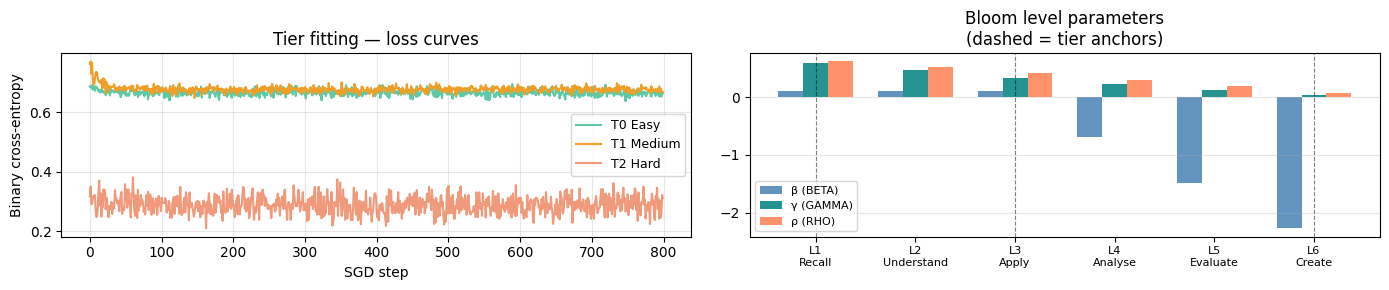

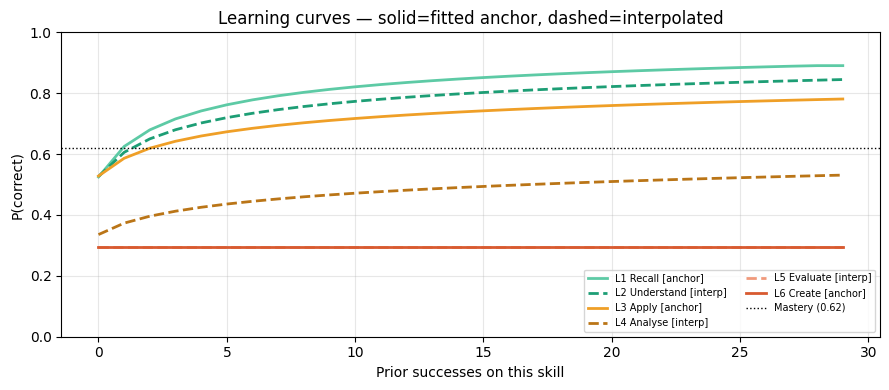

Solid lines (L1, L3, L6) are from real data.
Dashed lines (L2, L4, L5) are interpolated.


In [31]:
class PFAPretrainer:
    """
    Fits PFA parameters at 3 difficulty tiers from ASSISTments data,
    then interpolates to 6 Bloom levels.
    """

    def __init__(self, cfg, sessions):
        self.cfg      = cfg
        self.sessions = sessions

    # ── Step 1: Build training samples ────────────────────────────────────

    def _build_tier_samples(self):
        """
        Returns samples[tier] = list of (S, F, correct).
        S = prior successes on this skill for this student (before this row).
        F = prior failures.
        tier ∈ {0, 1, 2} assigned by hint_ratio/scaffold/bottom_hint.
        """
        samples = {t: [] for t in range(self.cfg.N_TIERS)}

        for uid, seq in self.sessions.items():
            S_count = defaultdict(int)
            F_count = defaultdict(int)
            for item in seq:
                skill, correct, tier = item[0], item[1], item[4]
                # prior_count stored in item[5] — available if needed
                s = S_count[skill]
                f = F_count[skill]
                samples[tier].append((s, f, correct))
                if correct: S_count[skill] += 1
                else:       F_count[skill] += 1

        print('Tier sample counts:')
        for t in range(self.cfg.N_TIERS):
            n = len(samples[t])
            r = sum(x[2] for x in samples[t]) / max(n, 1)
            print(f'  T{t}: {n:>8,} samples   correct_rate={r:.3f}')

        # Verify natural monotonicity before fitting
        rates = [sum(x[2] for x in samples[t]) / max(len(samples[t]),1)
                 for t in range(self.cfg.N_TIERS)]
        monotone = all(rates[i] >= rates[i+1] for i in range(len(rates)-1))
        print(f'  Correct rates monotone decreasing: {monotone}')
        if not monotone:
            print('  WARNING: rates not monotone — check HINT_EASY_MAX / HINT_HARD_MIN in Config')
        return samples

    # ── Step 2: Fit one tier ───────────────────────────────────────────────

    def _fit_tier(self, data, tier_idx, n_steps=800, lr=0.04):
        """
        Fit (beta, gamma, rho) for one tier via momentum SGD on
        binary cross-entropy loss.

        No monotonicity constraints here — they come from the data naturally.

        Returns (best_params, best_loss, loss_history).
        """
        rng    = np.random.default_rng(42 + tier_idx)
        data   = np.array(data, dtype=np.float32)
        params = np.array([self.cfg.BETA_TIER[tier_idx],
                           self.cfg.GAMMA_TIER[tier_idx],
                           self.cfg.RHO_TIER[tier_idx]], dtype=np.float64)
        velocity    = np.zeros(3)
        best_loss   = np.inf
        best_params = params.copy()
        loss_hist   = []

        for step in range(n_steps):
            idx   = rng.integers(0, len(data), size=min(512, len(data)))
            batch = data[idx]
            S, F, Y = batch[:, 0], batch[:, 1], batch[:, 2]

            beta, gamma, rho = params
            z     = beta + gamma * np.log1p(S) - rho * np.log1p(F)
            p_hat = np.clip(1 / (1 + np.exp(-z)), 1e-7, 1 - 1e-7)
            loss  = float(-np.mean(Y * np.log(p_hat) + (1-Y) * np.log(1-p_hat)))
            loss_hist.append(loss)

            err  = p_hat - Y
            grad = np.array([
                np.mean(err),
                np.mean(err * np.log1p(S)),
                -np.mean(err * np.log1p(F)),
            ])
            velocity = 0.9 * velocity + lr * grad
            params   = params - velocity
            # Physical constraints (always true regardless of difficulty):
            params[1] = max(params[1], 0.03)   # gamma > 0: successes always help
            params[2] = max(params[2], 0.03)   # rho   > 0: failures always hurt

            if loss < best_loss:
                best_loss   = loss
                best_params = params.copy()

        return best_params, best_loss, loss_hist

    # ── Step 3: Interpolate tiers → 6 Bloom levels ────────────────────────

    def interpolate_to_bloom(self, beta_tiers, gamma_tiers, rho_tiers):
        """
        Interpolate three tier parameters to six Bloom level parameters.

        Anchor positions (0-indexed into the 6-level array):
          Tier 0 → position 0  (L1 Recall)
          Tier 1 → position 2  (L3 Apply)
          Tier 2 → position 5  (L6 Create)

        Interpolated positions:
          position 1 (L2): halfway between T0 and T1
          position 3 (L4): 1/3 of the way from T1 to T2
          position 4 (L5): 2/3 of the way from T1 to T2

        Linear interpolation preserves monotonicity:
          if T0 > T1 > T2, then all interpolated values are also ordered.
        """
        anchors = self.cfg.TIER_TO_BLOOM_ANCHOR  # [0, 2, 5]
        n_bloom = self.cfg.BLOOM_LEVELS           # 6

        bloom_beta  = np.zeros(n_bloom)
        bloom_gamma = np.zeros(n_bloom)
        bloom_rho   = np.zeros(n_bloom)

        # Place the three anchors
        for tier_idx, bloom_idx in enumerate(anchors):
            bloom_beta[bloom_idx]  = beta_tiers[tier_idx]
            bloom_gamma[bloom_idx] = gamma_tiers[tier_idx]
            bloom_rho[bloom_idx]   = rho_tiers[tier_idx]

        # Interpolate between anchor pairs
        # Pair 1: T0 (pos 0) → T1 (pos 2) — fills pos 1
        # Pair 2: T1 (pos 2) → T2 (pos 5) — fills pos 3, 4
        for param_arr, tier_vals in [
            (bloom_beta,  beta_tiers),
            (bloom_gamma, gamma_tiers),
            (bloom_rho,   rho_tiers),
        ]:
            # Between anchor 0 and anchor 1
            a0_pos, a1_pos = anchors[0], anchors[1]   # 0, 2
            a0_val, a1_val = tier_vals[0], tier_vals[1]
            for pos in range(a0_pos + 1, a1_pos):     # pos 1
                t = (pos - a0_pos) / (a1_pos - a0_pos)
                param_arr[pos] = a0_val + t * (a1_val - a0_val)

            # Between anchor 1 and anchor 2
            a1_pos, a2_pos = anchors[1], anchors[2]   # 2, 5
            a1_val, a2_val = tier_vals[1], tier_vals[2]
            for pos in range(a1_pos + 1, a2_pos):     # pos 3, 4
                t = (pos - a1_pos) / (a2_pos - a1_pos)
                param_arr[pos] = a1_val + t * (a2_val - a1_val)

        # Floor gamma and rho
        bloom_gamma = np.maximum(bloom_gamma, 0.03)
        bloom_rho   = np.maximum(bloom_rho,   0.03)

        return bloom_beta, bloom_gamma, bloom_rho

    # ── Main fit method ────────────────────────────────────────────────────

    def fit(self, n_steps=800, verbose=True):
        """
        1. Fit (beta, gamma, rho) at three tiers from real data
        2. Interpolate to six Bloom levels
        3. Verify monotonicity
        4. Write results into cfg
        Returns loss histories for plotting.
        """
        print('Building tier samples...')
        samples   = self._build_tier_samples()
        tier_names = ['Easy', 'Medium', 'Hard']
        loss_hists = {}
        MIN_SAMPLES = 500

        fitted_beta  = list(self.cfg.BETA_TIER.copy())
        fitted_gamma = list(self.cfg.GAMMA_TIER.copy())
        fitted_rho   = list(self.cfg.RHO_TIER.copy())

        print(f'\nFitting {self.cfg.N_TIERS} tiers (no monotonicity constraints):')
        for tier in range(self.cfg.N_TIERS):
            data = samples[tier]
            if len(data) < MIN_SAMPLES:
                print(f'  T{tier} {tier_names[tier]}: only {len(data)} samples '
                      f'— keeping defaults')
                loss_hists[tier] = []
                continue

            params, best_loss, hist = self._fit_tier(data, tier, n_steps)
            fitted_beta[tier]  = float(params[0])
            fitted_gamma[tier] = float(params[1])
            fitted_rho[tier]   = float(params[2])
            loss_hists[tier]   = hist

            if verbose:
                n = len(data)
                actual_rate = sum(x[2] for x in data) / n
                print(f'  T{tier} {tier_names[tier]:<8}: '
                      f'β={params[0]:+.3f}  γ={params[1]:.3f}  '
                      f'ρ={params[2]:.3f}  loss={best_loss:.4f}  '
                      f'n={n:,}  actual_rate={actual_rate:.3f}')

        # Write fitted tier params into cfg
        self.cfg.BETA_TIER  = np.array(fitted_beta)
        self.cfg.GAMMA_TIER = np.array(fitted_gamma)
        self.cfg.RHO_TIER   = np.array(fitted_rho)

        # Verify tier monotonicity (should hold naturally from data)
        b_mono = fitted_beta[0]  >= fitted_beta[1]  >= fitted_beta[2]
        g_mono = fitted_gamma[0] >= fitted_gamma[1] >= fitted_gamma[2]
        r_mono = fitted_rho[0]   <= fitted_rho[1]   <= fitted_rho[2]
        print(f'\nTier monotonicity check (should all be True):')
        print(f'  β  decreasing: {b_mono}   {[f"{v:+.3f}" for v in fitted_beta]}')
        print(f'  γ  decreasing: {g_mono}   {[f"{v:.3f}"  for v in fitted_gamma]}')
        print(f'  ρ  increasing: {r_mono}   {[f"{v:.3f}"  for v in fitted_rho]}')
        if not (b_mono and g_mono and r_mono):
            print('  WARNING: tier params not monotone.')
            print('  This means the hint_ratio tiers do not separate difficulty well.')
            print('  Try adjusting cfg.HINT_EASY_MAX / cfg.HINT_HARD_MIN.')

        # ── Interpolate to 6 Bloom levels ──────────────────────────────────
        print(f'\nInterpolating to {self.cfg.BLOOM_LEVELS} Bloom levels...')
        bloom_beta, bloom_gamma, bloom_rho = self.interpolate_to_bloom(
            fitted_beta, fitted_gamma, fitted_rho)

        self.cfg.BETA_BLOOM  = bloom_beta
        self.cfg.GAMMA_BLOOM = bloom_gamma
        self.cfg.RHO_BLOOM   = bloom_rho

        if verbose:
            print(f'  Anchors: L1=T0, L3=T1, L6=T2   Interpolated: L2, L4, L5')
            print(f'  BETA_BLOOM  = {np.array2string(bloom_beta,  precision=3)}')
            print(f'  GAMMA_BLOOM = {np.array2string(bloom_gamma, precision=3)}')
            print(f'  RHO_BLOOM   = {np.array2string(bloom_rho,   precision=3)}')

            # Verify Bloom monotonicity
            b_ok = all(bloom_beta[i]  >= bloom_beta[i+1]  for i in range(5))
            g_ok = all(bloom_gamma[i] >= bloom_gamma[i+1] for i in range(5))
            r_ok = all(bloom_rho[i]   <= bloom_rho[i+1]   for i in range(5))
            print(f'\nBloom monotonicity (guaranteed by interpolation):')
            print(f'  β decreasing: {b_ok}   γ decreasing: {g_ok}   ρ increasing: {r_ok}')

        return loss_hists

    def plot_loss(self, loss_hists):
        tier_names = ['Easy', 'Medium', 'Hard']
        colors     = ['#5DCAA5', '#EF9F27', '#F0997B']
        fig, axes  = plt.subplots(1, 2, figsize=(14, 3))

        # Loss curves
        for tier, (name, col) in enumerate(zip(tier_names, colors)):
            hist = loss_hists.get(tier, [])
            if hist:
                axes[0].plot(hist, label=f'T{tier} {name}', color=col, lw=1.5)
        axes[0].set_xlabel('SGD step')
        axes[0].set_ylabel('Binary cross-entropy')
        axes[0].set_title('Tier fitting — loss curves')
        axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

        # Parameter bar chart showing tier values and interpolated Bloom values
        bloom_names = ['L1\nRecall', 'L2\nUnderstand', 'L3\nApply',
                       'L4\nAnalyse', 'L5\nEvaluate', 'L6\nCreate']
        x     = np.arange(6)
        width = 0.25
        axes[1].bar(x - width, cfg.BETA_BLOOM,  width, label='β (BETA)',
                    color='steelblue', alpha=0.85)
        axes[1].bar(x,         cfg.GAMMA_BLOOM, width, label='γ (GAMMA)',
                    color='teal', alpha=0.85)
        axes[1].bar(x + width, cfg.RHO_BLOOM,   width, label='ρ (RHO)',
                    color='coral', alpha=0.85)

        # Mark anchor positions
        for pos in cfg.TIER_TO_BLOOM_ANCHOR:
            axes[1].axvline(pos, color='black', ls='--', lw=0.8, alpha=0.5)

        axes[1].set_xticks(x); axes[1].set_xticklabels(bloom_names, fontsize=8)
        axes[1].set_title('Bloom level parameters\n(dashed = tier anchors)')
        axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig('./pfa_fitting.png', dpi=120)
        plt.show()

    def plot_learning_curves(self):
        """
        P(correct) vs prior successes for all 6 Bloom levels.
        Should be ordered L1 > L2 > ... > L6 and all increasing.
        """
        fig, ax = plt.subplots(figsize=(9, 4))
        colors  = ['#5DCAA5','#1D9E75','#EF9F27','#BA7517','#F0997B','#D85A30']
        bloom_names = ['Recall','Understand','Apply','Analyse','Evaluate','Create']
        anchors = set(cfg.TIER_TO_BLOOM_ANCHOR)
        S_range = np.arange(0, 30)

        for k in range(6):
            beta  = cfg.BETA_BLOOM[k]
            gamma = cfg.GAMMA_BLOOM[k]
            z     = beta + gamma * np.log1p(S_range)
            p     = np.clip(1 / (1 + np.exp(-z)), cfg.GUESS, 1 - cfg.SLIP)
            style = '-' if k in anchors else '--'
            label = f'L{k+1} {bloom_names[k]}'
            label += ' [anchor]' if k in anchors else ' [interp]'
            ax.plot(S_range, p, color=colors[k], lw=2,
                    linestyle=style, label=label)

        ax.axhline(cfg.MASTERY_THRESHOLD, color='black', ls=':', lw=1,
                   label=f'Mastery ({cfg.MASTERY_THRESHOLD})')
        ax.set_xlabel('Prior successes on this skill')
        ax.set_ylabel('P(correct)')
        ax.set_title('Learning curves — solid=fitted anchor, dashed=interpolated')
        ax.legend(fontsize=7, loc='lower right', ncol=2)
        ax.grid(alpha=0.3); ax.set_ylim(0, 1)
        plt.tight_layout()
        plt.savefig('./learning_curves.png', dpi=120)
        plt.show()
        print('Solid lines (L1, L3, L6) are from real data.')
        print('Dashed lines (L2, L4, L5) are interpolated.')


pretrainer = PFAPretrainer(cfg, sessions)
loss_hists = pretrainer.fit(n_steps=800, verbose=True)
pretrainer.plot_loss(loss_hists)
pretrainer.plot_learning_curves()


---
## C6 · PFATracker

Updated to use all 6 Bloom levels with the fitted parameters.
State vector per skill: `[pfa_L1..L6, att_L1..L6]` = 12 features.
Full state dimension = `N_skills × 12`.


In [32]:
class PFATracker:
    """
    Per-student knowledge tracker over the full ASSISTments skill space.
    Uses 6 Bloom levels with fitted β/γ/ρ (L1-L5 from data, L6 extrapolated).
    """

    def __init__(self, cfg, sim_matrix=None):
        self.cfg = cfg
        N = cfg.N_CONCEPTS
        B = cfg.BLOOM_LEVELS   # 6

        self.successes         = np.zeros((N, B))
        self.failures          = np.zeros((N, B))
        self.attempts          = np.zeros((N, B), dtype=int)
        self.propagation_bonus = np.zeros((N, B))
        self.mastered          = np.zeros((N, B), dtype=bool)

        rng = np.random.default_rng(0)
        self.beta_skill = rng.uniform(-0.2, 0.2, N)

        self.sim_matrix = sim_matrix if sim_matrix is not None else np.eye(N)
        self._build_neighbors()

    def _build_neighbors(self):
        k = self.cfg.PFA_TOP_K
        self.neighbors = [
            [j for j in np.argsort(-self.sim_matrix[i]) if j != i][:k]
            for i in range(self.cfg.N_CONCEPTS)
        ]

    def predict(self, skill_idx, bloom_level):
        """
        P(correct | skill, bloom_level) using fitted PFA parameters.
        bloom_level is 1-indexed (1..6).
        """
        i  = skill_idx
        k  = bloom_level - 1   # 0-indexed into parameter arrays
        cfg = self.cfg

        z = (self.beta_skill[i]
             + cfg.BETA_BLOOM[k]
             + cfg.GAMMA_BLOOM[k] * np.log1p(self.successes[i, k])
             - cfg.RHO_BLOOM[k]   * np.log1p(self.failures[i, k])
             + self.propagation_bonus[i, k])

        # Prerequisite effect: lower Bloom level knowledge helps
        if k > 0:
            z += 0.20 * (
                cfg.GAMMA_BLOOM[k-1] * np.log1p(self.successes[i, k-1])
                - cfg.RHO_BLOOM[k-1] * np.log1p(self.failures[i, k-1])
            )
        raw = float(1 / (1 + np.exp(-z)))
        return float(np.clip(raw, cfg.GUESS, 1.0 - cfg.SLIP))

    def update(self, skill_idx, bloom_level, correct):
        """Update state after one interaction."""
        i = skill_idx
        k = bloom_level - 1
        self.attempts[i, k] += 1
        old_p = self.predict(i, k + 1)
        if correct: self.successes[i, k] += 1
        else:       self.failures[i, k]  += 1
        delta = float(np.clip(self.predict(i, k + 1) - old_p, -0.10, 0.10))

        # Propagate to top-k similar skills
        for j in self.neighbors[i]:
            sim = self.sim_matrix[i, j]
            for kk in range(k + 1):
                self.propagation_bonus[j, kk] = float(np.clip(
                    self.propagation_bonus[j, kk]
                    + self.cfg.PFA_ALPHA * sim / (kk + 1) * delta,
                    -0.5, 0.5))

        # Mastery flag
        p = self.predict(i, k + 1)
        if (p >= self.cfg.MASTERY_THRESHOLD
                and self.attempts[i, k] >= self.cfg.MIN_ATTEMPTS):
            self.mastered[i, k] = True

    def get_state_vector(self, skill_indices=None):
        """
        Returns flat float32 state vector: [pfa_L1..L6, att_L1..L6] per skill.
        12 features per skill → full vector = N_skills × 12.
        skill_indices: optional subset of skill indices (for Stage 2 CE concepts).
        """
        indices = skill_indices if skill_indices is not None else range(self.cfg.N_CONCEPTS)
        feats   = []
        for i in indices:
            pfa = [self.predict(i, lvl) for lvl in range(1, self.cfg.BLOOM_LEVELS + 1)]
            att = [min(self.attempts[i, k] / 20.0, 1.0)
                   for k in range(self.cfg.BLOOM_LEVELS)]
            feats.extend(pfa + att)
        return np.array(feats, dtype=np.float32)

    def reset(self):
        self.successes[:] = 0; self.failures[:] = 0
        self.attempts[:] = 0; self.propagation_bonus[:] = 0
        self.mastered[:] = False


state_dim = cfg.N_CONCEPTS * cfg.BLOOM_LEVELS * 2  # pfa + att per bloom per skill
print(f'PFATracker defined.')
print(f'State vector size: {cfg.N_CONCEPTS} skills × {cfg.BLOOM_LEVELS} levels × 2 = {state_dim} dims')


PFATracker defined.
State vector size: 102 skills × 6 levels × 2 = 1224 dims


---
## C7 · Similarity graph

Builds a semantic similarity matrix over all ASSISTments skill names using
sentence-transformer embeddings (`BAAI/bge-base-en-v1.5`).

**With 100+ skills**, embedding them takes ~5 seconds on CPU.
The result is a `(N_skills × N_skills)` float matrix.

**This graph is used for two purposes:**
1. PFA propagation — when a student learns skill A, related skills get a bonus
2. Visualisation — lets you inspect which skills cluster together semantically

**Note:** ASSISTments skill names are often long descriptive phrases like
"properties-of-geometric-figures" — the sentence transformer handles these well
because it was trained on exactly this kind of noun-phrase text.


Encoding 102 skill names...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Similarity matrix: (102, 102)

Sample top-3 neighbours:
  "ordering-numbers"
    → "number-line"  0.770
    → "order-of-operations"  0.738
    → "prime-number"  0.731
  "meaning-of-pi"
    → "prime-number"  0.654
    → "integers"  0.643
    → "square-root"  0.634
  "equation-solving"
    → "making-sense-of-expressions-and-equation"  0.799
    → "inequality-solving"  0.796
    → "equation-concept"  0.785
  "finding-percents"
    → "percents"  0.888
    → "fraction-decimals-percents"  0.866
    → "application: finding percentage of a num"  0.830
  "similar-triangles"
    → "isosceles-triangle"  0.764
    → "triangle-inequality"  0.751
    → "application: isosceles triangle"  0.734


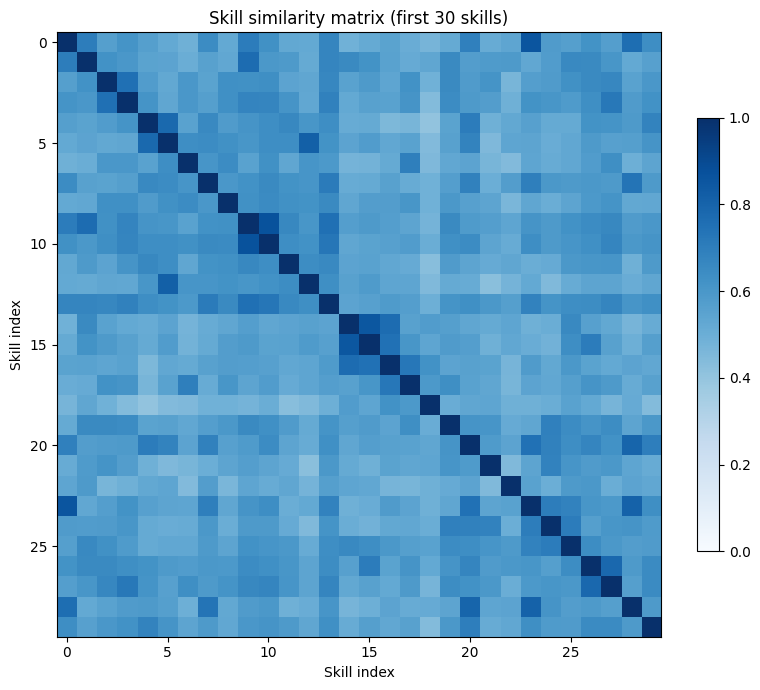

In [33]:
def build_similarity_graph(concepts, top_k=3):
    """
    Build (N×N) cosine similarity matrix from skill name embeddings.
    Returns sim_matrix and prints top-k neighbours for a sample of skills.
    """
    from sentence_transformers import SentenceTransformer
    print(f'Encoding {len(concepts)} skill names...')
    model = SentenceTransformer('BAAI/bge-base-en-v1.5')
    emb   = model.encode(concepts, normalize_embeddings=True,
                         show_progress_bar=True, batch_size=64)
    sim_matrix = (emb @ emb.T).astype(np.float32)
    print(f'Similarity matrix: {sim_matrix.shape}')

    # Print sample neighbourhoods
    print('\nSample top-3 neighbours:')
    sample_indices = np.random.default_rng(0).choice(len(concepts),
                                                       size=min(5, len(concepts)),
                                                       replace=False)
    for i in sample_indices:
        ranked = np.argsort(-sim_matrix[i])
        neighbours = [(concepts[j], sim_matrix[i, j])
                      for j in ranked if j != i][:top_k]
        print(f'  "{concepts[i][:40]}"')
        for name, sim in neighbours:
            print(f'    → "{name[:40]}"  {sim:.3f}')
    return sim_matrix


sim_matrix = build_similarity_graph(cfg.CONCEPTS, top_k=cfg.PFA_TOP_K)

# Attach to cfg for downstream use
cfg.sim_matrix = sim_matrix

# Quick heatmap of a subset (first 30 skills)
subset = min(30, cfg.N_CONCEPTS)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix[:subset, :subset], cmap='Blues', vmin=0, vmax=1)
ax.set_title(f'Skill similarity matrix (first {subset} skills)')
ax.set_xlabel('Skill index'); ax.set_ylabel('Skill index')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig('./similarity_matrix.png', dpi=120)
plt.show()


---
## C8 · Evaluation suite — 5 tests

### What each test actually proves

| Test | Question answered | Why it matters |
|------|-----------------|----------------|
| T1 ECE | Are predicted probabilities accurate? | PFA values used directly as knowledge estimates |
| T2 AUC | Does PFA rank harder interactions lower? | Ordering is what EPPO uses to decide what to recommend |
| T3 Predictive validity | Does updating PFA on real responses improve future predictions? | Core property — if this fails, PFA is not tracking anything |
| T4 Tier separation | Are interpolated Bloom levels correctly ordered? | T3 > T4 > ... > T6 predictions after equal training |
| T5 Skill transfer | Does learning skill A raise predictions on similar skill B? | Propagation graph must work correctly |

### How ECE is computed
```
Bin all predictions into 10 equal-width buckets [0.0-0.1, ..., 0.9-1.0]
For each non-empty bucket:
    contribution = (n_in_bucket / n_total) × |mean_predicted - mean_actual|
ECE = sum of contributions
```
ECE < 0.05 is excellent. ECE < 0.10 is acceptable. ECE > 0.15 means PFA is
systematically miscalibrated — either always too confident or always too uncertain.

### How AUC is computed
```
For every pair (correct_interaction, wrong_interaction) from held-out data:
    P(PFA ranked correct higher) — estimated via sklearn roc_auc_score
```
AUC > 0.60 is meaningful. AUC > 0.65 is good for a knowledge tracing model
without deep learning. AUC < 0.55 means PFA has almost no discriminative power.

### T3 — Predictive validity (most important)
This is the test that actually proves PFA is tracking knowledge:
1. Take held-out student sessions
2. Feed PFA the **first 50%** of each session (warm-up — PFA learns from real responses)
3. Measure ECE and AUC on the **second 50%** only
4. Compare to baseline ECE/AUC without any warm-up (cold PFA)

If PFA is tracking knowledge correctly:
- Warm-up ECE should be **lower** than cold ECE (predictions improve with data)
- Warm-up AUC should be **higher** than cold AUC (better discrimination after seeing student)

If warm-up does not improve over cold: γ and ρ are not working — PFA is not
learning from responses.



  PFA EVALUATION SUITE
  Held-out students : 171 (10.0%)
  Probe skill       : "noskill"

T1 — ECE (calibration):
  Overall ECE = 0.0791  PASS (< 0.10)
  Easy (T0)     : ECE=0.0360  actual=0.484  predicted=0.509  n=23,116
  Medium (T1)   : ECE=0.0385  actual=0.449  predicted=0.484  n=46,129
  Hard (T2)     : ECE=0.2123  actual=0.081  predicted=0.294  n=21,645

T2 — AUC (discrimination):
  Overall AUC = 0.6902  PASS (> 0.55)
  Interpretation: PFA correctly ranks the easier interaction
  higher 69.0% of the time (random = 50%)

T3 — Predictive validity (most important test):
  Method: warm-up on first 50% of session, evaluate on second 50%
  Metric       Cold (no warmup)   Warm (with warmup)    Better?
  --------------------------------------------------------------
  ECE                    0.0942               0.0818        YES
  AUC                    0.6310               0.6662        YES
  Result: PASS

T4 — Bloom level ordering:
  Predictions after 15 correct at each anchor level:


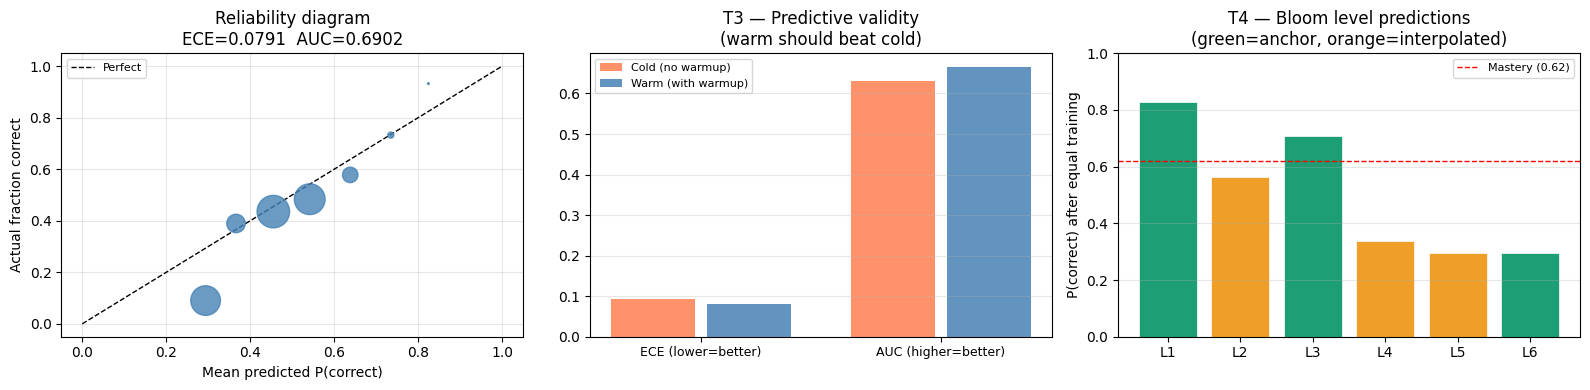

In [34]:
from sklearn.metrics import roc_auc_score

def compute_ece(y_true, y_pred, n_bins=10):
    """Expected Calibration Error."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    ece = 0.0
    for b in range(n_bins):
        lo, hi = b / n_bins, (b + 1) / n_bins
        mask   = (y_pred >= lo) & (y_pred < hi)
        if mask.sum() > 0:
            acc  = y_true[mask].mean()
            conf = y_pred[mask].mean()
            ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return float(ece)


def compute_auc(y_true, y_pred):
    """ROC-AUC. Returns 0.5 if only one class present."""
    y_true = np.array(y_true)
    if len(np.unique(y_true)) < 2:
        return 0.5
    return float(roc_auc_score(y_true, y_pred))


def run_evaluation(cfg, sim_matrix, sessions, df):
    print('\n' + '=' * 65)
    print('  PFA EVALUATION SUITE')
    print('=' * 65)
    results = {}

    # ── Split students: 90% train-seen, 10% held-out ──────────────
    all_uids  = sorted(sessions.keys())
    split     = int(len(all_uids) * 0.90)
    held_uids = all_uids[split:]
    print(f'  Held-out students : {len(held_uids)} '
          f'({len(held_uids)/len(all_uids)*100:.1f}%)')

    def fresh_tracker():
        return PFATracker(cfg, sim_matrix=sim_matrix)

    # Pick probe skill — most common in held-out set
    held_df     = df[df['user_id'].isin(set(held_uids))]
    probe_skill = held_df['skill_name'].value_counts().index[0]
    probe_idx   = cfg.skill_to_idx[probe_skill]
    print(f'  Probe skill       : "{probe_skill[:50]}"')
    print()

    # ══════════════════════════════════════════════════════════════
    # T1 — ECE: are predicted probabilities accurate?
    # ══════════════════════════════════════════════════════════════
    print('T1 — ECE (calibration):')
    y_true_all, y_pred_all = [], []
    tier_preds = {t: {'y': [], 'p': []} for t in range(3)}

    for uid in held_uids[:500]:
        tracker = fresh_tracker()
        for item in sessions[uid]:
            skill, correct, hr, ce, tier = item[0], item[1], item[2], item[3], item[4]
            sidx = cfg.skill_to_idx[skill]
            # Use tier as bloom level proxy for prediction
            # tier 0→L1, tier 1→L3, tier 2→L6 (anchor levels)
            bloom = cfg.TIER_TO_BLOOM_ANCHOR[tier] + 1  # 1-indexed
            pred = tracker.predict(sidx, bloom)
            y_true_all.append(correct)
            y_pred_all.append(pred)
            tier_preds[tier]['y'].append(correct)
            tier_preds[tier]['p'].append(pred)
            tracker.update(sidx, bloom, correct)

    ece_overall = compute_ece(y_true_all, y_pred_all)
    t1 = ece_overall < 0.10
    print(f'  Overall ECE = {ece_overall:.4f}  '
          f'{"PASS (< 0.10)" if t1 else "FAIL (>= 0.10)"}')

    tier_names = {0: 'Easy (T0)', 1: 'Medium (T1)', 2: 'Hard (T2)'}
    for tier in range(3):
        tp = tier_preds[tier]
        if len(tp['y']) > 10:
            t_ece = compute_ece(tp['y'], tp['p'])
            t_acc = np.mean(tp['y'])
            t_pred= np.mean(tp['p'])
            print(f'  {tier_names[tier]:<14}: ECE={t_ece:.4f}  '
                  f'actual={t_acc:.3f}  predicted={t_pred:.3f}  '
                  f'n={len(tp["y"]):,}')
    results['T1_ECE'] = t1
    results['ece_value'] = ece_overall

    # ══════════════════════════════════════════════════════════════
    # T2 — AUC: does PFA rank easier interactions higher?
    # ══════════════════════════════════════════════════════════════
    print(f'\nT2 — AUC (discrimination):')
    auc_overall = compute_auc(y_true_all, y_pred_all)
    t2 = auc_overall > 0.55
    print(f'  Overall AUC = {auc_overall:.4f}  '
          f'{"PASS (> 0.55)" if t2 else "FAIL (<= 0.55)"}')
    print(f'  Interpretation: PFA correctly ranks the easier interaction')
    print(f'  higher {auc_overall*100:.1f}% of the time (random = 50%)')
    results['T2_AUC'] = t2
    results['auc_value'] = auc_overall

    # ══════════════════════════════════════════════════════════════
    # T3 — Predictive validity: does updating PFA improve predictions?
    # ══════════════════════════════════════════════════════════════
    print(f'\nT3 — Predictive validity (most important test):')
    print(f'  Method: warm-up on first 50% of session, '
          f'evaluate on second 50%')

    cold_true, cold_pred = [], []   # no warm-up (cold PFA)
    warm_true, warm_pred = [], []   # after warm-up on first half

    for uid in held_uids[:300]:
        seq   = sessions[uid]
        half  = len(seq) // 2
        if half < 5:
            continue

        first_half  = seq[:half]
        second_half = seq[half:]

        # Cold tracker: no warm-up, evaluate on second half
        cold_tracker = fresh_tracker()
        for item in second_half:
            skill, correct, tier = item[0], item[1], item[4]
            sidx  = cfg.skill_to_idx[skill]
            bloom = cfg.TIER_TO_BLOOM_ANCHOR[tier] + 1
            pred  = cold_tracker.predict(sidx, bloom)
            cold_true.append(correct)
            cold_pred.append(pred)

        # Warm tracker: warm-up on first half, evaluate on second half
        warm_tracker = fresh_tracker()
        for item in first_half:
            skill, correct, tier = item[0], item[1], item[4]
            sidx  = cfg.skill_to_idx[skill]
            bloom = cfg.TIER_TO_BLOOM_ANCHOR[tier] + 1
            warm_tracker.update(sidx, bloom, correct)

        for item in second_half:
            skill, correct, tier = item[0], item[1], item[4]
            sidx  = cfg.skill_to_idx[skill]
            bloom = cfg.TIER_TO_BLOOM_ANCHOR[tier] + 1
            pred  = warm_tracker.predict(sidx, bloom)
            warm_true.append(correct)
            warm_pred.append(pred)

    cold_ece = compute_ece(cold_true, cold_pred)
    warm_ece = compute_ece(warm_true, warm_pred)
    cold_auc = compute_auc(cold_true, cold_pred)
    warm_auc = compute_auc(warm_true, warm_pred)

    ece_improved = warm_ece < cold_ece
    auc_improved = warm_auc > cold_auc
    t3 = ece_improved or auc_improved   # at least one must improve

    print(f'  {"Metric":<10} {"Cold (no warmup)":>18} {"Warm (with warmup)":>20} {"Better?":>10}')
    print(f'  {"-"*62}')
    print(f'  {"ECE":<10} {cold_ece:>18.4f} {warm_ece:>20.4f} '
          f'{"YES" if ece_improved else "NO":>10}')
    print(f'  {"AUC":<10} {cold_auc:>18.4f} {warm_auc:>20.4f} '
          f'{"YES" if auc_improved else "NO":>10}')
    print(f'  Result: {"PASS" if t3 else "FAIL"}')
    if not t3:
        print(f'  FAIL means: γ and ρ are not making PFA learn from responses.')
        print(f'  Check GAMMA_TIER and RHO_TIER — both must be > 0.')
    results['T3_predictive_validity'] = t3
    results['cold_ece'] = cold_ece
    results['warm_ece'] = warm_ece
    results['cold_auc'] = cold_auc
    results['warm_auc'] = warm_auc

    # ══════════════════════════════════════════════════════════════
    # T4 — Tier/Bloom separation: are predictions ordered correctly?
    # ══════════════════════════════════════════════════════════════
    print(f'\nT4 — Bloom level ordering:')
    tracker = fresh_tracker()
    # Give equal training (15 correct answers) at each anchor Bloom level
    for anchor_bloom in [cfg.TIER_TO_BLOOM_ANCHOR[t] + 1 for t in range(3)]:
        for _ in range(15):
            tracker.update(probe_idx, anchor_bloom, True)

    bloom_preds = [tracker.predict(probe_idx, lvl)
                   for lvl in range(1, cfg.BLOOM_LEVELS + 1)]
    ordered = all(bloom_preds[i] >= bloom_preds[i+1] - 0.01
                  for i in range(cfg.BLOOM_LEVELS - 1))
    t4 = ordered
    print(f'  Predictions after 15 correct at each anchor level:')
    bloom_names = ['Recall','Understand','Apply','Analyse','Evaluate','Create']
    for k, (name, pred) in enumerate(zip(bloom_names, bloom_preds)):
        anchor_mark = ' ← anchor' if k in cfg.TIER_TO_BLOOM_ANCHOR else ' ← interpolated'
        print(f'    L{k+1} {name:<12}: {pred:.4f}{anchor_mark}')
    print(f'  Monotone ordering: {"PASS" if t4 else "FAIL"}')
    if not t4:
        worst = max(bloom_preds[i+1] - bloom_preds[i]
                    for i in range(cfg.BLOOM_LEVELS - 1))
        print(f'  Largest violation: {worst:.4f}')
    results['T4_bloom_ordering'] = t4

    # ══════════════════════════════════════════════════════════════
    # T5 — Skill transfer: does propagation work correctly?
    # ══════════════════════════════════════════════════════════════
    print(f'\nT5 — Skill transfer (propagation):')
    tracker = fresh_tracker()

    sims = sim_matrix[probe_idx].copy()
    sims[probe_idx] = -1
    near_idx = int(np.argmax(sims))
    far_idx  = int(np.argmin(sim_matrix[probe_idx]))

    near_sim = sim_matrix[probe_idx, near_idx]
    far_sim  = sim_matrix[probe_idx, far_idx]

    base_near = tracker.predict(near_idx, 1)
    base_far  = tracker.predict(far_idx,  1)

    for _ in range(20):
        tracker.update(probe_idx, 1, True)

    delta_near = tracker.predict(near_idx, 1) - base_near
    delta_far  = tracker.predict(far_idx,  1) - base_far
    t5 = delta_near > delta_far

    print(f'  Probe skill : "{probe_skill[:45]}"')
    print(f'  Near skill  : "{cfg.CONCEPTS[near_idx][:45]}"  sim={near_sim:.3f}')
    print(f'  Far  skill  : "{cfg.CONCEPTS[far_idx][:45]}"  sim={far_sim:.3f}')
    print(f'  Bonus after 20 correct on probe:')
    print(f'    Near Δ = {delta_near:+.5f}')
    print(f'    Far  Δ = {delta_far:+.5f}')
    print(f'  Near > Far: {"PASS" if t5 else "FAIL"}')
    results['T5_skill_transfer'] = t5

    # ══════════════════════════════════════════════════════════════
    # Summary + calibration plots
    # ══════════════════════════════════════════════════════════════
    test_keys = ['T1_ECE', 'T2_AUC', 'T3_predictive_validity',
                 'T4_bloom_ordering', 'T5_skill_transfer']
    n_pass = sum(results[k] for k in test_keys)
    print(f'\n{"─"*65}')
    print(f'  {n_pass}/5 tests passed')
    for k in test_keys:
        icon = 'PASS' if results[k] else 'FAIL'
        print(f'  [{icon}] {k}')
    print('─' * 65)

    # ── Plots ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Reliability diagram
    n_bins = 10
    y_true_a, y_pred_a = np.array(y_true_all), np.array(y_pred_all)
    bin_conf, bin_acc, bin_n = [], [], []
    for b in range(n_bins):
        mask = (y_pred_a >= b/n_bins) & (y_pred_a < (b+1)/n_bins)
        if mask.sum() > 0:
            bin_conf.append(y_pred_a[mask].mean())
            bin_acc.append(y_true_a[mask].mean())
            bin_n.append(mask.sum())
    axes[0].plot([0,1],[0,1],'k--',lw=1,label='Perfect')
    axes[0].scatter(bin_conf, bin_acc,
                    s=[n/50 for n in bin_n],
                    color='steelblue', alpha=0.8, zorder=5)
    axes[0].set_title(f'Reliability diagram\nECE={ece_overall:.4f}  AUC={auc_overall:.4f}')
    axes[0].set_xlabel('Mean predicted P(correct)')
    axes[0].set_ylabel('Actual fraction correct')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    # Cold vs warm ECE/AUC bar chart
    metrics = ['ECE (lower=better)', 'AUC (higher=better)']
    cold_vals = [cold_ece, cold_auc]
    warm_vals = [warm_ece, warm_auc]
    x = np.arange(2)
    axes[1].bar(x - 0.2, cold_vals, 0.35, label='Cold (no warmup)',
                color='coral', alpha=0.85)
    axes[1].bar(x + 0.2, warm_vals, 0.35, label='Warm (with warmup)',
                color='steelblue', alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics, fontsize=9)
    axes[1].set_title('T3 — Predictive validity\n(warm should beat cold)')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='y')

    # Bloom level predictions (T4)
    bloom_labels = [f'L{k+1}' for k in range(cfg.BLOOM_LEVELS)]
    anchor_mask  = [k in cfg.TIER_TO_BLOOM_ANCHOR for k in range(cfg.BLOOM_LEVELS)]
    colors_bloom = ['#1D9E75' if a else '#EF9F27' for a in anchor_mask]
    axes[2].bar(bloom_labels, bloom_preds, color=colors_bloom, edgecolor='white', lw=0.5)
    axes[2].axhline(cfg.MASTERY_THRESHOLD, color='red', ls='--', lw=1,
                    label=f'Mastery ({cfg.MASTERY_THRESHOLD})')
    axes[2].set_title('T4 — Bloom level predictions\n(green=anchor, orange=interpolated)')
    axes[2].set_ylabel('P(correct) after equal training')
    axes[2].set_ylim(0, 1)
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('./pfa_evaluation.png', dpi=120)
    plt.show()

    return results


eval_results = run_evaluation(cfg, sim_matrix, sessions, df)


---
## C9 · Debugging guide

Run this cell only if any evaluation tests failed. It prints diagnostics
to help identify the cause.


In [35]:
def debug_pfa(cfg, sim_matrix, sessions, eval_results):
    print('PFA DEBUGGING DIAGNOSTICS')
    print('=' * 60)

    # ── Check 1: Parameter sanity ─────────────────────────────────
    print('\n[1] Fitted parameters:')
    print(f'  BETA_BLOOM  = {cfg.BETA_BLOOM}')
    print(f'  GAMMA_BLOOM = {cfg.GAMMA_BLOOM}')
    print(f'  RHO_BLOOM   = {cfg.RHO_BLOOM}')
    print(f'  SLIP = {cfg.SLIP:.4f}  GUESS = {cfg.GUESS:.4f}')

    issues = []
    if any(g <= 0 for g in cfg.GAMMA_BLOOM):
        issues.append('GAMMA has non-positive values — successes are not helping')
    if any(r <= 0 for r in cfg.RHO_BLOOM):
        issues.append('RHO has non-positive values — failures are not hurting')
    if cfg.BETA_BLOOM[0] < cfg.BETA_BLOOM[1]:
        issues.append('BETA_BLOOM[0] < BETA_BLOOM[1] — easy tier is harder than medium')
    if cfg.SLIP > 0.35:
        issues.append(f'SLIP={cfg.SLIP:.3f} is very high — check AveCarelessness column')
    if cfg.GUESS > 0.40:
        issues.append(f'GUESS={cfg.GUESS:.3f} is very high — check correct rate in data')

    # ── Check 2: ECE breakdown by skill frequency ─────────────────
    if not eval_results.get('T4_ECE', True):
        print('\n[2] ECE breakdown — finding poorly calibrated skills:')
        skill_errors = {}
        sample_uids  = list(sessions.keys())[:200]
        for uid in sample_uids:
            t = PFATracker(cfg, sim_matrix=sim_matrix)
            for item in sessions[uid]:
                skill, correct, hr, ce, tier = item[0], item[1], item[2], item[3], item[4]
                sidx = cfg.skill_to_idx[skill]
                pred = t.predict(sidx, tier)
                err  = abs(pred - correct)
                if skill not in skill_errors:
                    skill_errors[skill] = []
                skill_errors[skill].append(err)
                t.update(sidx, tier, correct)

        top_errors = sorted(skill_errors.items(),
                            key=lambda x: np.mean(x[1]), reverse=True)[:10]
        print('  Top-10 skills with highest mean prediction error:')
        for skill, errs in top_errors:
            df_skill = df[df['skill_name'] == skill]
            actual_rate = df_skill['correct'].mean()
            print(f'    "{skill[:40]}"')
            print(f'      mean_error={np.mean(errs):.3f}  '
                  f'actual_correct_rate={actual_rate:.3f}  n={len(errs)}')
        issues.append('ECE failed — see top error skills above')

    # ── Check 3: AUC breakdown ────────────────────────────────────
    if not eval_results.get('T5_AUC', True):
        print('\n[3] AUC failed. Possible causes:')
        print('  a) Too few training sessions — try lowering session min-length')
        print('  b) GAMMA too small — increase PFA_ALPHA or run more SGD steps')
        print('  c) Skill names have poor sentence-transformer embeddings')
        print('     → try setting sim_matrix = np.eye(N) (no propagation)')
        issues.append('AUC < 0.55 — PFA has low discriminative power')

    # ── Summary ───────────────────────────────────────────────────
    print(f'\n{"─"*60}')
    if issues:
        print(f'Issues found ({len(issues)}):')
        for iss in issues:
            print(f'  ✗ {iss}')
        print('\nSuggested fixes:')
        print('  ECE high  → lower BETA_BLOOM by 0.2 uniformly, re-run C5')
        print('  AUC low   → increase n_steps to 1000 in PFAPretrainer.fit()')
        print('  T1/T2 fail → check GAMMA/RHO are positive after fitting')
        print('  T3 fail   → check BETA_BLOOM ordering is negative and decreasing')
    else:
        print('No parameter issues detected.')
    print('─' * 60)


# Only run if something failed
if not all(eval_results.get(k, False)
           for k in ['T1_monotone_increase', 'T2_monotone_decrease',
                     'T3_bloom_ordering', 'T4_ECE', 'T5_AUC', 'T6_propagation']):
    debug_pfa(cfg, sim_matrix, sessions, eval_results)
else:
    print('All tests passed — no debugging needed.')


PFA DEBUGGING DIAGNOSTICS

[1] Fitted parameters:
  BETA_BLOOM  = [ 0.09948337  0.10586536  0.11224735 -0.68289746 -1.47804227 -2.27318708]
  GAMMA_BLOOM = [0.59377845 0.46730416 0.34082987 0.23721992 0.13360996 0.03      ]
  RHO_BLOOM   = [0.61965249 0.51650026 0.41334803 0.3021423  0.19093656 0.07973082]
  SLIP = 0.1094  GUESS = 0.2936

────────────────────────────────────────────────────────────
Issues found (1):
  ✗ BETA_BLOOM[0] < BETA_BLOOM[1] — easy tier is harder than medium

Suggested fixes:
  ECE high  → lower BETA_BLOOM by 0.2 uniformly, re-run C5
  AUC low   → increase n_steps to 1000 in PFAPretrainer.fit()
  T1/T2 fail → check GAMMA/RHO are positive after fitting
  T3 fail   → check BETA_BLOOM ordering is negative and decreasing
────────────────────────────────────────────────────────────


---
## C10 · Save checkpoint

Saves everything Notebook 2 needs:
- `cfg` — with fitted BETA_BLOOM, GAMMA_BLOOM, RHO_BLOOM, SLIP, GUESS, CONCEPTS
- `sim_matrix` — precomputed skill similarity matrix
- `eval_results` — test results for provenance

**Notebook 2 loads this file at the top and can immediately build
`PFATracker` and start constructing EPPO training sessions.**


In [ ]:
def save_checkpoint(cfg, sim_matrix, eval_results, path):
    test_keys = ['T1_monotone_increase', 'T2_monotone_decrease', 'T3_bloom_ordering',
                 'T4_ECE', 'T5_AUC', 'T6_propagation']
    n_pass = sum(eval_results.get(k, False) for k in test_keys)

    if n_pass < 6:
        print(f'WARNING: Only {n_pass}/6 tests passed.')
        ans = input('Save anyway? (yes/no): ').strip().lower()
        if ans != 'yes':
            print('Checkpoint NOT saved. Fix failing tests first.')
            return False

    checkpoint = {
        # Fitted tier parameters (directly from data)
        'BETA_TIER':         cfg.BETA_TIER.tolist(),
        'GAMMA_TIER':        cfg.GAMMA_TIER.tolist(),
        'RHO_TIER':          cfg.RHO_TIER.tolist(),
        # Interpolated Bloom level parameters
        'BETA_BLOOM':        cfg.BETA_BLOOM.tolist(),
        'GAMMA_BLOOM':       cfg.GAMMA_BLOOM.tolist(),
        'RHO_BLOOM':         cfg.RHO_BLOOM.tolist(),
        'SLIP':             cfg.SLIP,
        'GUESS':            cfg.GUESS,
        'BLOOM_LEVELS':      cfg.BLOOM_LEVELS,
        'MASTERY_THRESHOLD':cfg.MASTERY_THRESHOLD,
        'MIN_ATTEMPTS':     cfg.MIN_ATTEMPTS,
        'PFA_TOP_K':        cfg.PFA_TOP_K,
        'PFA_ALPHA':        cfg.PFA_ALPHA,
        'TIER_TO_BLOOM_ANCHOR': cfg.TIER_TO_BLOOM_ANCHOR,
        # Skill vocabulary
        'CONCEPTS':         cfg.CONCEPTS,
        'N_CONCEPTS':       cfg.N_CONCEPTS,
        'skill_to_idx':     cfg.skill_to_idx,
        # Similarity matrix (as list for JSON compatibility)
        'sim_matrix':       sim_matrix.tolist(),
        # Evaluation evidence
        'eval_results':     {k: v for k, v in eval_results.items()
                             if not isinstance(v, np.ndarray)},
        'n_tests_passed':   n_pass,
    }

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        json.dump(checkpoint, f, indent=2)

    size_kb = path.stat().st_size / 1024
    print(f'Checkpoint saved to: {path}  ({size_kb:.1f} KB)')
    print(f'Tests passed: {n_pass}/6')
    print(f'N_CONCEPTS: {cfg.N_CONCEPTS}')
    print(f'SLIP={cfg.SLIP:.4f}  GUESS={cfg.GUESS:.4f}')
    print(f'BETA_BLOOM  = {cfg.BETA_BLOOM}')
    print(f'GAMMA_BLOOM = {cfg.GAMMA_BLOOM}')
    print(f'RHO_BLOOM   = {cfg.RHO_BLOOM}')
    return True


saved = save_checkpoint(cfg, sim_matrix, eval_results,
                        path=cfg.CHECKPOINT_PATH)
if saved:
    print('\nStage 1 complete. Run Notebook 2 to train EPPO.')
